<left>
<table style='margin-top:0px; margin-left:0px;'>
<tr>
  <td><img src='https://raw.githubusercontent.com/worm-portal/WORM-Figures/master/style/worm.png' alt='WORM' title='WORM' width=50/></td>
  <td><h1 style=font-size:30px>Media Speciator</h1><h2>Notebook</h2></td>
</tr>
</table>
</left>
<p><img src="https://res.cloudinary.com/dcqwdxisc/image/upload/f_auto,q_auto/IMG_6490_nhtouf" alt="aqueous environments" border="0"></p>

<p>This notebook applies aqueous chemical speciation to microbial media recipes using an established thermodynamic modeling package (Boyer et al., 2024). Given a solution composition, along with defined pH and temperature, it calculates how ions are distributed among free species and complexes. This provides insight into what is actually bioavailable in the medium and how solution chemistry shifts under different conditions.</p>

<p>Documentation of the AqEquil package for speciation can be found <a href="https://worm-portal.asu.edu/AqEquil-docs/AqSpeciation.html" rel="nofollow">here</a>.</p>

In [1]:
import aqequil
ae = aqequil.AqEquil(db="WORM")

Loading Water-Organic-Rock-Microbe (WORM) thermodynamic databases...
wrm_data_latest.csv is now set as the active thermodynamic database.
Element database elements.csv is active.
Solid solution database solid_solutions.csv is active.
LogK database wrm_data_logK.csv is active.
LogK_S database wrm_data_logK_S.csv is active.
Loading thermodynamic database into pyCHNOSZ...


In [2]:
# perform a speciation calculation
speciation = ae.speciate(input_filename="example-speciation-input.csv", #formatted_file
                         exclude=["Name","Year"],
                         report_filename="speciation_output.csv", # create a CSV of results 
                         delete_generated_folders=True)
                         #charge_balance_on='HCO3-')

speciation.save("speciation-for-energy") #save file for energy supply step

The input file column 'logfO2' will be used to set sample redox state. If a another column is desired, set it manually using the redox_flag parameter.
Getting wrm_data_latest.csv ready. This will take a moment...
No 'charge_balance_on' column found in input file. Defaulting to no charge balancing for all samples.
Using wrm_data_latest.csv to speciate River Source
Using wrm_data_latest.csv to speciate River Recipe
Using wrm_data_latest.csv to speciate Hot Spring Source
Using wrm_data_latest.csv to speciate Hot Spring Recipe
Using wrm_data_latest.csv to speciate Hydrothermal Vent Source
Using wrm_data_latest.csv to speciate Hydrothermal Vent Recipe
Finished!
Saved as 'speciation-for-energy.speciation'


This plot shows the % mass contribution of complexes containing a given basis species. This species can be changed depending on what you want to look at.

In [3]:
speciation.plot_mass_contribution('SO4-2', sort_by="Year", ascending=True)

### Energy Supplies

The next code will allow you to calculate the energy supplies of your medium and/or original sample geochemistry data. The top n number of reactions are then printed in tables and plotted as a bar chart. (explain generally how this is calculated)

You can start here any time after speciating.

In [5]:
#import tools for looking at top energy supplies
from media_design import *

info_character: found water(liq); also available in water
The WORM thermodynamic database has been loaded: 1735 aqueous, 2022 total species


In [6]:
import aqequil
ae = aqequil.AqEquil(db="WORM")
speciation = aqequil.load("speciation-for-energy.speciation")

Loading Water-Organic-Rock-Microbe (WORM) thermodynamic databases...
wrm_data_latest.csv is now set as the active thermodynamic database.
Element database elements.csv is active.
Solid solution database solid_solutions.csv is active.
LogK database wrm_data_logK.csv is active.
LogK_S database wrm_data_logK_S.csv is active.
Loading thermodynamic database into pyCHNOSZ...
Loaded 'speciation-for-energy.speciation'


In [7]:
#make all possible redox reactions of the half reactions available by default in the package
speciation.make_redox_reactions()
speciation.redox_formatted_reactions.to_csv("formatted_redox_rxns")

,redox_pairs,reaction
reaction_name,,
rxn_0_3,"[0, 3]",SO4-2 + 8 H+ + 3 pyrite = 3 Fe+2 + 7 sulfur + 4 H2O
rxn_3_0,"[3, 0]",3 Fe+2 + 7 sulfur + 4 H2O = SO4-2 + 8 H+ + 3 pyrite
rxn_0_4,"[0, 4]",SO4-2 + 3 H2S + 2 H+ = 4 sulfur + 4 H2O
rxn_4_0,"[4, 0]",4 sulfur + 4 H2O = SO4-2 + 3 H2S + 2 H+
rxn_0_5,"[0, 5]",SO4-2 + 3 Fe+2 + 6 H2S = 4 H+ + 3 pyrite + sulfur + 4 H2O
rxn_5_0,"[5, 0]",4 H+ + 3 pyrite + sulfur + 4 H2O = SO4-2 + 3 Fe+2 + 6 H2S
rxn_0_6,"[0, 6]",SO4-2 + 2 H+ + 6 magnetite + 8 H2O = sulfur + 18 goethite
rxn_6_0,"[6, 0]",sulfur + 18 goethite = SO4-2 + 2 H+ + 6 magnetite + 8 H2O
rxn_0_7,"[0, 7]",SO4-2 + 6 Fe+2 + 8 H2O = 10 H+ + sulfur + 6 goethite


In [8]:
#calculate the energy supplies
speciation.apply_redox_reactions(y_type='E',
                                 y_units='J')
speciation.save("speciation-with-energy")

IntProgress(value=0, max=300)

Saved as 'speciation-with-energy.speciation'


In [9]:
#get a file of just the energy supplies for visual analysis
df = speciation.lookup(speciation.lookup('energy supply'))
df.columns = ['_'.join(col).strip() for col in df.columns.values]
df.to_csv("energy-supplies.csv")

In [10]:
#print the top energy supplies
print_top_energy_supplies(
    energy_file="energy-supplies.csv",
    reaction_file="formatted_redox_rxns",
    sample_name_col="Sample",
    top_n=5 #however many rxns you want to see
)

Reaction,Energy Supply (J/kg fluid)
2 O2 + NH3 = NO3- + H+ + H2O,8226.256
23 H+ + 4 magnetite + NH3 = NO3- + 12 Fe+2 + 13 H2O,8226.148
4 hematite + 15 H+ + NH3 = NO3- + 8 Fe+2 + 9 H2O,8222.132
15 H+ + NH3 + 8 goethite = NO3- + 8 Fe+2 + 13 H2O,8222.076
12 hematite + NH3 = NO3- + H+ + 8 magnetite + H2O,8214.101


Reaction,Energy Supply (J/kg fluid)
2 O2 + NH3 = NO3- + H+ + H2O,8227.029
23 H+ + 4 magnetite + NH3 = NO3- + 12 Fe+2 + 13 H2O,8227.008
4 hematite + 15 H+ + NH3 = NO3- + 8 Fe+2 + 9 H2O,8222.960
15 H+ + NH3 + 8 goethite = NO3- + 8 Fe+2 + 13 H2O,8222.903
12 hematite + NH3 = NO3- + H+ + 8 magnetite + H2O,8214.863


Reaction,Energy Supply (J/kg fluid)
SO4-2 + 2 H+ + 8 magnetite = 12 hematite + H2S,13.005
3 O2 + 2 sulfur + 2 H2O = 2 SO4-2 + 4 H+,4.664
O2 + 4 magnetite = 6 hematite,4.564
O2 + 4 magnetite + 6 H2O = 12 goethite,4.426
7 O2 + 2 pyrite + 2 H2O = 4 SO4-2 + 2 Fe+2 + 4 H+,4.331


Reaction,Energy Supply (J/kg fluid)
3 O2 + 2 sulfur + 2 H2O = 2 SO4-2 + 4 H+,33.847
O2 + 4 magnetite = 6 hematite,32.546
O2 + 4 magnetite + 6 H2O = 12 goethite,31.719
7 O2 + 2 pyrite + 2 H2O = 4 SO4-2 + 2 Fe+2 + 4 H+,31.440
O2 + 4 H+ + 2 pyrite = 2 Fe+2 + 4 sulfur + 2 H2O,16.999


Reaction,Energy Supply (J/kg fluid)
SO4-2 + 2 H+ + 8 magnetite = 12 hematite + H2S,1006.877
SO4-2 + 2 H+ + 6 magnetite = 9 hematite + sulfur + H2O,687.015
SO4-2 + 2 H+ + 8 magnetite + 12 H2O = H2S + 24 goethite,651.383
SO4-2 + 2 H+ + 6 magnetite + 8 H2O = sulfur + 18 goethite,420.395
H2S + 22 H+ + 4 magnetite = SO4-2 + 12 Fe+2 + 12 H2O,325.032


Reaction,Energy Supply (J/kg fluid)
SO4-2 + 2 H+ + 8 magnetite = 12 hematite + H2S,625.608
SO4-2 + 2 H+ + 6 magnetite = 9 hematite + sulfur + H2O,422.664
SO4-2 + 2 H+ + 8 magnetite + 12 H2O = H2S + 24 goethite,363.117
H2S + 22 H+ + 4 magnetite = SO4-2 + 12 Fe+2 + 12 H2O,314.107
SO4-2 + 2 H+ + 6 magnetite + 8 H2O = sulfur + 18 goethite,225.796


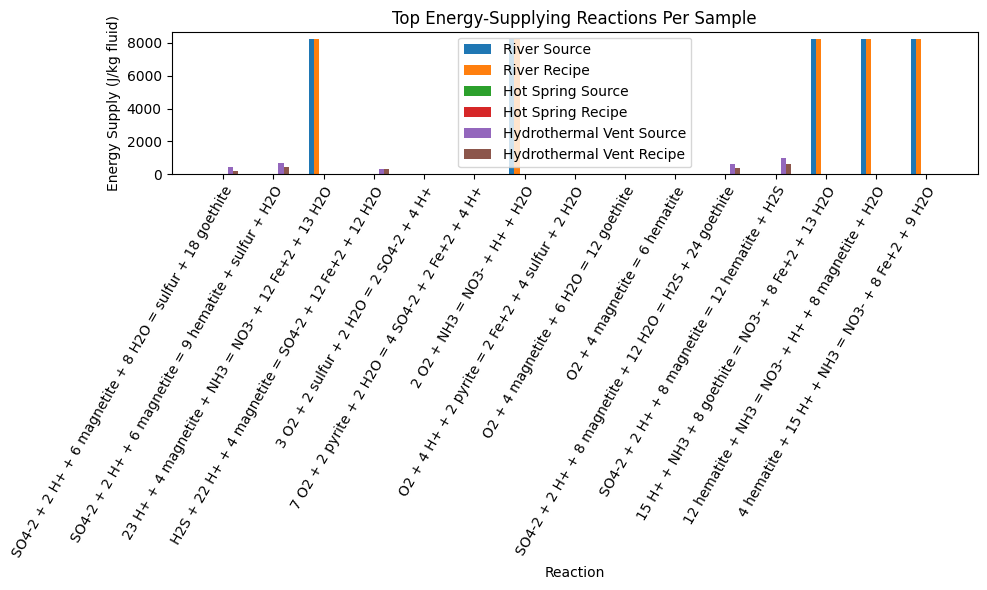

In [11]:
#plot the top energy supplies
plot_top_energy_supplies(
    energy_file="energy-supplies.csv",
    reaction_file="formatted_redox_rxns",
    sample_name_col="Sample",
    top_n=5 #however many top rxns you want to see
)